# Assignment 13 — Good vs Bad Exercise Classifier

**Pipeline:**
1. Load the A12 Start/Stop model (`@prod`) to cut raw sequences to the exercise window  
2. Augment the cut sequences (mirror, rotate, scale, noise) 
3. Add extra per-frame features: inter-joint distances + limb angles  
4. Resample every sequence to **c = 10** equidistant frames  
5. Train two classifiers
6. Evaluate with confusion matrix, AUC, Precision, Recall, Accuracy
7. Manual checking on preprcessed files 

## Imports

In [ ]:
import os, glob, sys, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    confusion_matrix, roc_auc_score,
    precision_score, recall_score, accuracy_score,
    ConfusionMatrixDisplay
)
import mlflow
import mlflow.pytorch
import dagshub
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

sys.path.append('../../scripts')
import ml_utils as mlutils

All imports OK


In [ ]:
def get_feat_cols(columns):
    return [c for c in columns if '_3d_' in c]


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False



class ActivityGatekeeper(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bidirectional = config.get('bidirectional', False)
        multiplier = 2 if self.bidirectional else 1
        rnn_cls    = nn.GRU if config.get('rnn_type', 'LSTM') == 'GRU' else nn.LSTM
        self.rnn = rnn_cls(
            config['input_size'], config['hidden_size'], config['num_layers'],
            batch_first   = True,
            dropout       = config['dropout'] if config['num_layers'] > 1 else 0,
            bidirectional = self.bidirectional,
        )
        act = config.get('activation', 'identity')
        self.act = nn.ReLU() if act == 'relu' else (nn.Tanh() if act == 'tanh' else nn.Identity())
        self.fc  = nn.Linear(config['hidden_size'] * multiplier, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(self.act(out[:, -1, :]))

## DagsHub Setup & Load Start/Stop Model

In [ ]:
dagshub.init(repo_owner='SamuelFredricBerg', repo_name='4dt907', mlflow=True)

SS_PROJECT  = 'Start_Stop_Predictor_ModelV2'
A13_PROJECT = 'GoodBad_ClassifierV2'

utils  = mlutils.mlutils(A13_PROJECT)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


# This config i got from dagshub to match with the actual start/stop model
SS_CONFIG = {
    'rnn_type': 'LSTM', 'bidirectional': False,
    'hidden_size': 128,  'num_layers': 2,
    'seq_length': 5,    'input_size': 39,
    'dropout': 0.1,     'activation': 'identity',
    'use_scaling': False,
}

ss_model = ActivityGatekeeper(SS_CONFIG).to(device)
ss_model.load_state_dict(torch.load('best_start_stop_model_prod.pth', map_location=device))
ss_model.eval()
ss_config = SS_CONFIG

Initialized MLflow to track repo "SamuelFredricBerg/4dt907"

Repository SamuelFredricBerg/4dt907 initialized!

Device: cpu


## Cut Raw Sequences with the Start/Stop Model

In [ ]:
DATA_DIR  = '../../data/kinect_good_vs_bad_not_preprocessed_A13_mediapipe'
# We need the actual training sequence to be a miniumum of 10 frames
MIN_SEQ   = 10


def is_good_exercise(filepath):
    """True for A1 and G-prefix files, False for W-prefix files."""
    base = os.path.splitext(os.path.basename(filepath))[0] 
    name = base.replace('_kinect', '')
    return name == 'A1' or name.upper().startswith('G')


def cut_with_model(df, model, config, device, scaler=None, min_length=MIN_SEQ):
    feat_cols = get_feat_cols(df.columns)
    X = df[feat_cols].values.astype('float32')
    if scaler is not None:
        X = scaler.transform(X)

    seq_len = config['seq_length']
    preds   = [0] * (seq_len - 1)

    with torch.no_grad():
        for i in range(len(df) - seq_len + 1):
            window = torch.tensor(X[i:i + seq_len]).unsqueeze(0).to(device)
            prob   = torch.sigmoid(model(window)).item()
            preds.append(1 if prob >= 0.5 else 0)

    active = np.where(np.array(preds) == 1)[0]
    if len(active) == 0:
        return None

    cut = df.iloc[active[0]: active[-1] + 1].reset_index(drop=True)
    return cut if len(cut) >= min_length else None



all_csv = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
print(f'Found {len(all_csv)} CSV files in data dir')

raw_sequences = []
skipped       = []

for f in tqdm(all_csv, desc='Cutting sequences'):
    df = pd.read_csv(f)

    cut_df = cut_with_model(df, ss_model, ss_config, device)

    if cut_df is None:
        # Skips if cutting error or if too short
        skipped.append(os.path.basename(f))
        continue

    feat_cols = get_feat_cols(cut_df.columns)
    feat_arr  = cut_df[feat_cols].values.astype('float32')
    label     = 1 if is_good_exercise(f) else 0

    raw_sequences.append((feat_arr, label, f, feat_cols))

n_good = sum(1 for _, l, _, _ in raw_sequences if l == 1)
n_bad  = sum(1 for _, l, _, _ in raw_sequences if l == 0)
print(f'\nKept {len(raw_sequences)} sequences  (good={n_good}, bad={n_bad})')
print(f'Skipped {len(skipped)}: {skipped}')

Found 114 CSV files in data dir


Cutting sequences: 100%|██████████| 114/114 [00:16<00:00,  6.73it/s]


✅ Kept 110 sequences  (good=71, bad=39)
   Skipped 4: ['W02.csv', 'W03.csv', 'W18.csv', 'W23.csv']


## Data Augmentation

Augmentations applied per original sequence:

| Transform | Variants |
|-----------|----------|
| Mirror (flip x, swap L/R joints) | 1 |
| Rotate around y-axis | −10°, −5°, +5°, +10° |
| Scale xyz | (0.95,1,1), (1.05,1,1), (1,0.95,1), (1,1.05,1), (0.95,0.95,0.95), (1.05,1.05,1.05) |
| Mirror + Rotate | −5°, +5° |
| Mirror + Scale | 0.95, 1.05 (uniform) |
| Gaussian noise | σ=0.005 |


In [ ]:
LEFT_RIGHT_PAIRS = [
    ('left_shoulder', 'right_shoulder'),
    ('left_elbow',    'right_elbow'),
    ('left_wrist',    'right_wrist'),
    ('left_hip',      'right_hip'),
    ('left_knee',     'right_knee'),
    ('left_ankle',    'right_ankle'),
]


def _col_idx(feat_cols, joint, axis):
    try:
        return feat_cols.index(f'{joint}_3d_{axis}')
    except ValueError:
        return -1


def aug_mirror(arr, feat_cols):
    """Mirror on the y-axis: flip x, swap left/right joints."""
    a = arr.copy()
    x_idxs = [i for i, c in enumerate(feat_cols) if c.endswith('_3d_x')]
    a[:, x_idxs] = 1.0 - a[:, x_idxs]

    for left, right in LEFT_RIGHT_PAIRS:
        for ax in ['x', 'y', 'z']:
            li = _col_idx(feat_cols, left,  ax)
            ri = _col_idx(feat_cols, right, ax)
            if li == -1 or ri == -1:
                continue
            a[:, li], a[:, ri] = arr[:, ri].copy(), arr[:, li].copy()
            if ax == 'x':
                a[:, li] = 1.0 - a[:, li]
                a[:, ri] = 1.0 - a[:, ri]
    return a


def aug_rotate_y(arr, feat_cols, angle_deg):
    """Rotate all joints around the y-axis by angle_deg degrees."""
    a     = arr.copy()
    theta = np.radians(angle_deg)
    c, s  = np.cos(theta), np.sin(theta)

    x_idxs = [i for i, col in enumerate(feat_cols) if col.endswith('_3d_x')]
    z_idxs = [i for i, col in enumerate(feat_cols) if col.endswith('_3d_z')]

    for xi, zi in zip(x_idxs, z_idxs):
        xv, zv = arr[:, xi].copy(), arr[:, zi].copy()
        a[:, xi] =  c * xv + s * zv
        a[:, zi] = -s * xv + c * zv
    return a


def aug_scale(arr, feat_cols, sx=1.0, sy=1.0, sz=1.0):
    """Scale x/y/z coordinates independently."""
    a = arr.copy()
    for i, c in enumerate(feat_cols):
        if   c.endswith('_3d_x'): a[:, i] = arr[:, i] * sx
        elif c.endswith('_3d_y'): a[:, i] = arr[:, i] * sy
        elif c.endswith('_3d_z'): a[:, i] = arr[:, i] * sz
    return a


def aug_noise(arr, sigma=0.005):
    """Add Gaussian noise."""
    return arr + np.random.normal(0, sigma, arr.shape).astype('float32')



def generate_variants(arr, feat_cols):
    variants = [arr]

    m = aug_mirror(arr, feat_cols)
    variants.append(m)

    for deg in [-10, -5, 5, 10]:
        variants.append(aug_rotate_y(arr, feat_cols, deg))

    for sx, sy, sz in [
        (0.95, 1.0,  1.0),
        (1.05, 1.0,  1.0),
        (1.0,  0.95, 1.0),
        (1.0,  1.05, 1.0),
        (0.95, 0.95, 0.95),
        (1.05, 1.05, 1.05),
    ]:
        variants.append(aug_scale(arr, feat_cols, sx, sy, sz))

    for deg in [-5, 5]:
        variants.append(aug_rotate_y(m, feat_cols, deg))

    for s in [0.95, 1.05]:
        variants.append(aug_scale(m, feat_cols, s, s, s))

    variants.append(aug_noise(arr, sigma=0.005))
    variants.append(aug_noise(arr, sigma=0.010))

    for deg in [-15, 15]:
        variants.append(aug_rotate_y(arr, feat_cols, deg))
    for deg in [-3, 3]:
        variants.append(aug_rotate_y(m, feat_cols, deg))
    for s in [0.90, 1.10]:
        variants.append(aug_scale(arr, feat_cols, s, s, s))
    variants.append(aug_noise(m, sigma=0.005))

    return variants



augmented_pool = []

for gid, (arr, label, orig_path, feat_cols) in enumerate(tqdm(raw_sequences, desc='Augmenting')):
    for v in generate_variants(arr, feat_cols):
        augmented_pool.append((v, label, gid))

n_aug_good = sum(1 for _, l, _ in augmented_pool if l == 1)
n_aug_bad  = sum(1 for _, l, _ in augmented_pool if l == 0)
print(f'Augmented pool: {len(augmented_pool)} sequences  '
      f'(good={n_aug_good}, bad={n_aug_bad})')


Augmenting: 100%|██████████| 110/110 [00:00<00:00, 421.01it/s]

✅ Augmented pool: 2750 sequences  (good=1775, bad=975)


## Feature Engineering: Distances & Angles

After augmentation we enrich each frame with:
- **16 normalised inter-joint distances** (key bone/limb pairs)  
- **6 joint angles** (cosine of bend angle at elbow/knee/shoulder)

In [ ]:
FEAT_COLS = raw_sequences[0][3]
N_BASE    = len(FEAT_COLS)
print(f'Base features per frame: {N_BASE} ({N_BASE // 3} joints × 3)')


KEY_DIST_PAIRS = [
    ('left_shoulder',  'right_shoulder'),
    ('left_elbow',     'right_elbow'),
    ('left_wrist',     'right_wrist'),
    ('left_hip',       'right_hip'),
    ('left_knee',      'right_knee'),
    ('left_ankle',     'right_ankle'),
    ('left_shoulder',  'left_elbow'),
    ('left_elbow',     'left_wrist'),
    ('right_shoulder', 'right_elbow'),
    ('right_elbow',    'right_wrist'),
    ('left_hip',       'left_knee'),
    ('left_knee',      'left_ankle'),
    ('right_hip',      'right_knee'),
    ('right_knee',     'right_ankle'),
    ('left_shoulder',  'left_hip'),
    ('right_shoulder', 'right_hip'),
]

KEY_ANGLE_TRIPLES = [
    ('left_shoulder',  'left_elbow',  'left_wrist'),
    ('right_shoulder', 'right_elbow', 'right_wrist'),
    ('left_hip',       'left_knee',   'left_ankle'),
    ('right_hip',      'right_knee',  'right_ankle'),
    ('left_elbow',     'left_shoulder',  'left_hip'),
    ('right_elbow',    'right_shoulder', 'right_hip'),
]


def _pos(arr, feat_cols, joint):
    idxs = []
    for ax in ['x', 'y', 'z']:
        col = f'{joint}_3d_{ax}'
        if col not in feat_cols:
            return None
        idxs.append(feat_cols.index(col))
    return arr[:, idxs]


def add_dist_angle_features(arr, feat_cols):
    """
    arr: (n_frames, n_base_features)
    Returns: (n_frames, n_base_features + n_dist + n_angle)
    """
    extras = []

    p_ls = _pos(arr, feat_cols, 'left_shoulder')
    p_rs = _pos(arr, feat_cols, 'right_shoulder')
    if p_ls is not None and p_rs is not None:
        scale = np.linalg.norm(p_rs - p_ls, axis=1, keepdims=True).mean() + 1e-8
    else:
        scale = 1.0

    for j1, j2 in KEY_DIST_PAIRS:
        p1 = _pos(arr, feat_cols, j1)
        p2 = _pos(arr, feat_cols, j2)
        if p1 is not None and p2 is not None:
            d = np.linalg.norm(p2 - p1, axis=1, keepdims=True) / scale
            extras.append(d)

    for ja, jv, jb in KEY_ANGLE_TRIPLES:
        pa = _pos(arr, feat_cols, ja)
        pv = _pos(arr, feat_cols, jv)
        pb = _pos(arr, feat_cols, jb)
        if pa is not None and pv is not None and pb is not None:
            va = pa - pv
            vb = pb - pv
            cos = (np.sum(va * vb, axis=1) /
                   (np.linalg.norm(va, axis=1) * np.linalg.norm(vb, axis=1) + 1e-8))
            extras.append(cos.reshape(-1, 1))

    if extras:
        return np.hstack([arr] + extras).astype('float32')
    return arr


_test = add_dist_angle_features(augmented_pool[0][0], FEAT_COLS)
N_FEAT = _test.shape[1]
print(f'Features per frame after enrichment: {N_FEAT}  '
      f'(+{N_FEAT - N_BASE} distance/angle features)')

Base features per frame: 39 (13 joints × 3)
Features per frame after enrichment: 61  (+22 distance/angle features)


## Fixed-Size Sequences (c = 10 frames)

Each cut sequence is resampled to **c = 10** frames.
FrameNo is not a feature — only the 3-D coordinates (+ distances/angles) are used.

In [ ]:
C = 10   # fixed number of frames


def to_fixed_length(arr, c=C):
    """Sample c equidistant rows from arr (includes first & last)."""
    n = len(arr)
    if n == c:
        return arr
    if n < c:
        pad = np.zeros((c - n, arr.shape[1]), dtype='float32')
        return np.vstack([arr, pad])
    idx = np.round(np.linspace(0, n - 1, c)).astype(int)
    return arr[idx]


X_seq  = []
y_all  = []
grp_all = []

for (arr, label, gid) in tqdm(augmented_pool, desc='Resampling to c=10'):
    enriched = add_dist_angle_features(arr, FEAT_COLS)
    fixed    = to_fixed_length(enriched, C)
    X_seq.append(fixed)
    y_all.append(label)
    grp_all.append(gid)

X_seq   = np.array(X_seq,   dtype='float32')
X_flat  = X_seq.reshape(len(X_seq), -1)
y_all   = np.array(y_all,   dtype='float32')
grp_all = np.array(grp_all)

INPUT_DENSE = X_flat.shape[1]
print(f'Dataset ready:')
print(f'Sequences : {len(X_seq)}')
print(f'Shape 3D  : {X_seq.shape}  (N, C, features)')
print(f'Dense input dim : {INPUT_DENSE}  ({C} frames × {N_FEAT} features)')
print(f'Good: {int(y_all.sum())}   Bad: {int((1-y_all).sum())}')

Resampling to c=10: 100%|██████████| 2750/2750 [00:01<00:00, 2274.26it/s]

Dataset ready:
  Sequences : 2750
  Shape 3D  : (2750, 10, 61)  (N, C, features)
  Dense input dim : 610  (10 frames × 61 features)
  Good: 1775   Bad: 975


## Model Definitions

### ADense — Dense-only (~10 000 parameters)

### ACNN — Conv1D + Dense (≤ 20 % of ADense params ≈ 2 000)


In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)



class ADense(nn.Module):
    def __init__(self, input_dim, h1=24, h2=12, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, 1),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.xavier_uniform_(m.weight)

    def forward(self, x):
        return self.net(x)



class ACNN(nn.Module):
    def __init__(self, n_feat, seq_len=C, n_filters=8, kernel_size=3,
                 pool_size=2, fc_h=16, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_feat, n_filters, kernel_size=kernel_size,
                      padding=kernel_size // 2, stride=1),
            nn.ReLU(),
            nn.MaxPool1d(pool_size),
        )
        conv_out = n_filters * (seq_len // pool_size)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(conv_out, fc_h),
            nn.ReLU(),
            nn.Linear(fc_h, 1),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.xavier_uniform_(m.weight)
            elif isinstance(m, nn.Conv1d):
                init.kaiming_normal_(m.weight)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        return self.fc(self.conv(x))


_h1, _h2 = 16, 8
_h1 = max(8, int(9000 / INPUT_DENSE))
_h2 = max(4, _h1 // 2)

_dense_demo = ADense(INPUT_DENSE, _h1, _h2)
_p_dense    = count_params(_dense_demo)

_cnn_demo = ACNN(N_FEAT, seq_len=C, n_filters=8, kernel_size=3, pool_size=2, fc_h=16)
_p_cnn    = count_params(_cnn_demo)

print(f'ADense  params: {_p_dense:>6,}  (target ≤ 10 000)')
print(f'ACNN    params: {_p_cnn:>6,}  (target ≤ {int(0.20 * _p_dense):,} = 20% of ADense)')
# This is just a sanity check
if _p_cnn > 0.20 * _p_dense + 200:
    print(f'ACNN too large: {_p_cnn} > 20% of {_p_dense}.')
else:
    print('Parameter budget satisfied')

ADense  params:  8,695  (target ≤ 10 000)
ACNN    params:  2,145  (target ≤ 1,739 = 20% of ADense)
ACNN too large: 2145 > 20% of 8695. Reduce n_filters or fc_h.


## Dataset, Metrics & Training Utilities

In [ ]:
import copy
from contextlib import nullcontext

class GoodBadDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


def compute_pos_weight_array(y, device):
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    if n_pos == 0:
        return torch.tensor([1.0], device=device)
    return torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)


def run_epoch(model, loader, optimizer, criterion, device, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_probs, all_labels = [], []

    ctx = nullcontext() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train:
                optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            probs = torch.sigmoid(logits).detach().cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(yb.cpu().numpy().flatten())

    p = np.array(all_probs)
    l = np.array(all_labels).astype(int)
    d = (p >= 0.5).astype(int)
    avg_loss = total_loss / len(loader)
    try:    auc  = roc_auc_score(l, p)
    except: auc  = float('nan')
    prec = precision_score(l, d, zero_division=0)
    rec  = recall_score(l, d, zero_division=0)
    return avg_loss, auc, prec, rec


def evaluate_metrics(model, loader, device, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            probs = torch.sigmoid(model(xb.to(device))).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(yb.numpy().flatten())

    probs  = np.array(all_probs)
    labels = np.array(all_labels).astype(int)
    preds  = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    try:    auc = roc_auc_score(labels, probs)
    except: auc = float('nan')
    return {
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'AUC':       float(auc),
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),
        'probs':     probs,
        'labels':    labels,
        'preds':     preds,
    }



PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)


def _pad_history(lst, length):
    fill = lst[-1] if lst else 0.0
    return lst + [fill] * (length - len(lst))


def plot_training_curves(histories, note, n_params, save=True):
    max_ep = max(len(h['train_loss']) for h in histories)

    def avg(key):
        return np.mean([_pad_history(h[key], max_ep) for h in histories], axis=0)

    epochs = np.arange(1, max_ep + 1)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{note}   ({n_params:,} params)', fontsize=13)

    panels = [
        ('train_loss', 'val_loss', 'Loss',      axes[0, 0]),
        ('train_auc',  'val_auc',  'AUC',       axes[0, 1]),
        ('train_prec', 'val_prec', 'Precision', axes[1, 0]),
        ('train_rec',  'val_rec',  'Recall',    axes[1, 1]),
    ]
    for tr_key, vl_key, ylabel, ax in panels:
        ax.plot(epochs, avg(tr_key), '-',  label='Train', color='steelblue')
        ax.plot(epochs, avg(vl_key), '--', label='Val',   color='steelblue', alpha=0.7)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    path = os.path.join(PLOTS_DIR, f'training_curves_{note}.png')
    if save:
        fig.savefig(path, dpi=120, bbox_inches='tight')
        print(f'  Saved training curves -> {path}')
    plt.show()
    plt.close(fig)
    return path


def plot_confusion_matrix_variant(all_labels, all_preds, all_probs, note, metrics, n_params, save=True):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'{note}   ({n_params:,} params)', fontsize=13)

    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Pred Bad', 'Pred Good'],
        yticklabels=['True Bad', 'True Good'],
        ax=axes[0]
    )
    axes[0].set_title(
        f'Confusion matrix @0.50\n'
        f'Acc={metrics["accuracy"]:.3f}  P={metrics["precision"]:.3f}  '
        f'R={metrics["recall"]:.3f}  AUC={metrics["AUC"]:.3f}'
    )
    axes[0].set_xlabel('Predicted label')
    axes[0].set_ylabel('Actual label')

    good_p = all_probs[all_labels == 1]
    bad_p  = all_probs[all_labels == 0]
    axes[1].hist(bad_p,  bins=20, alpha=0.6, color='tomato',    label='Bad (W*)')
    axes[1].hist(good_p, bins=20, alpha=0.6, color='steelblue', label='Good (G*/A1)')
    axes[1].axvline(0.5, color='black', linestyle='--', label='threshold=0.5')
    axes[1].set_xlabel('Predicted probability (good)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Score distributions')
    axes[1].legend()

    plt.tight_layout()
    path = os.path.join(PLOTS_DIR, f'confusion_{note}.png')
    if save:
        fig.savefig(path, dpi=120, bbox_inches='tight')
        print(f'  Saved confusion matrix -> {path}')
    plt.show()
    plt.close(fig)
    return path



print('Plots will be saved to:', PLOTS_DIR)


Utilities ready  |  plots will be saved to: plots


## Experiment Configuration

In [ ]:
N_FOLDS    = 10
SEED       = 42
set_seed(SEED)


DENSE_VARIANTS = [
    {
        'note':        'ADense_v1_baseline',
        'model_type':  'dense',
        'h1':          _h1,
        'h2':          _h2,
        'dropout':     0.3,
        'lr':          1e-3,
        'batch_size':  64,
        'epochs':      80,
        'patience':    10,
        'use_scaling': True,
    },
    {
        'note':        'ADense_v2_nodropout',
        'model_type':  'dense',
        'h1':          _h1,
        'h2':          _h2,
        'dropout':     0.0,
        'lr':          1e-3,
        'batch_size':  64,
        'epochs':      80,
        'patience':    10,
        'use_scaling': False,
    },
    {
        'note':        'ADense_v3_slowlr',
        'model_type':  'dense',
        'h1':          _h1,
        'h2':          _h2,
        'dropout':     0.5,
        'lr':          1e-4,
        'batch_size':  128,
        'epochs':      80,
        'patience':    15,
        'use_scaling': True,
    },
]



CNN_VARIANTS = [
    {
        'note':        'ACNN_v1_baseline',
        'model_type':  'cnn',
        'n_filters':   8,
        'kernel_size': 3,
        'pool_size':   2,
        'fc_h':        16,
        'dropout':     0.3,
        'lr':          1e-3,
        'batch_size':  64,
        'epochs':      80,
        'patience':    10,
        'use_scaling': True,
    },
    {
        'note':        'ACNN_v2_largekernel',
        'model_type':  'cnn',
        'n_filters':   4,
        'kernel_size': 7,
        'pool_size':   2,
        'fc_h':        8,
        'dropout':     0.3,
        'lr':          1e-3,
        'batch_size':  64,
        'epochs':      80,
        'patience':    10,
        'use_scaling': True,
    },
    {
        'note':        'ACNN_v3_nopool',
        'model_type':  'cnn',
        'n_filters':   4,
        'kernel_size': 3,
        'pool_size':   1,
        'fc_h':        8,
        'dropout':     0.4,
        'lr':          5e-4,
        'batch_size':  64,
        'epochs':      80,
        'patience':    10,
        'use_scaling': True,
    },
]

ALL_VARIANTS = DENSE_VARIANTS + CNN_VARIANTS

✅ Seed set to 42
Total experiment variants: 6


## 10-Fold Cross-Validation + MLflow Training

- Test fold uses **original-only** sequences (no augmentation), so the metric is unbiased  
- Scaler is fitted on the training slice only
- `BCEWithLogitsLoss` with `pos_weight` handles class imbalance  
- Early stopping on validation BCE loss

✅ Seed set to 42
  Fold  1 | AUC=1.000  Acc=0.909  P=0.875  R=1.000  TP=7  FP=1  TN=3  FN=0
  Fold  2 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  3 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  4 | AUC=1.000  Acc=0.909  P=0.875  R=1.000  TP=7  FP=1  TN=3  FN=0
  Fold  5 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  6 | AUC=1.000  Acc=0.909  P=1.000  R=0.857  TP=6  FP=0  TN=4  FN=1
  Fold  7 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=8  FP=0  TN=3  FN=0
  Fold  8 | AUC=1.000  Acc=0.909  P=0.875  R=1.000  TP=7  FP=1  TN=3  FN=0
  Fold  9 | AUC=1.000  Acc=0.909  P=0.857  R=1.000  TP=6  FP=1  TN=4  FN=0
  Fold 10 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=8  FP=0  TN=3  FN=0

--- ADense_v1_baseline (8,695 params) ---
10-fold averages: AUC=1.0000  Acc=0.9545  Prec=0.9482  Rec=0.9857
  Saved training curves -> plots/training_curves_ADense_v1_baseline.png


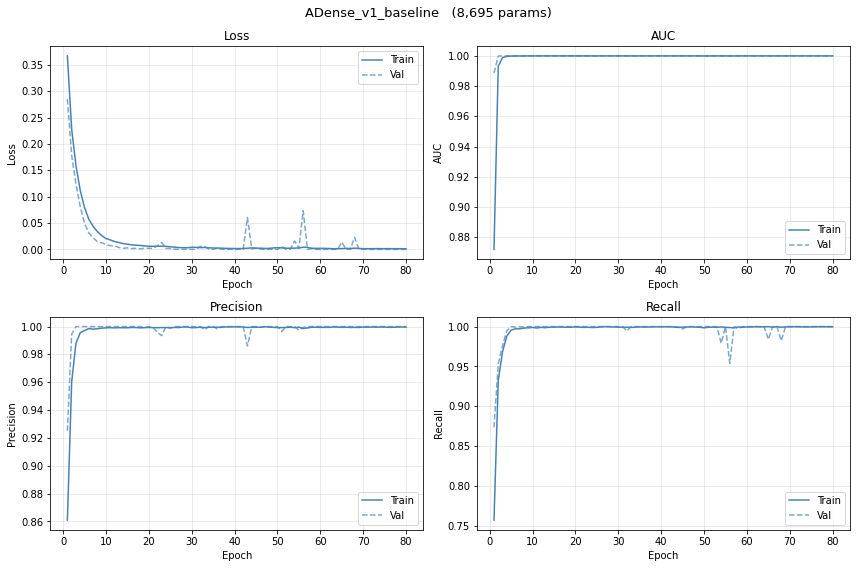

  Saved confusion matrix -> plots/confusion_ADense_v1_baseline.png


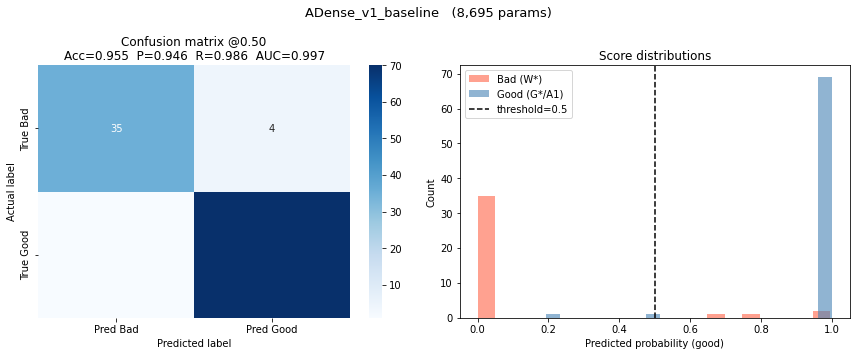

Comparing 0.9545454545454545 > 0.9636363636363636
  Model ADense_v1_baseline did not beat @dev.
🏃 View run A13 - ADense_v1_baseline at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/d2d098aacbaa4dda81fe24a33303c923
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
✅ Seed set to 42
  Fold  1 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  2 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  3 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  4 | AUC=1.000  Acc=0.909  P=0.875  R=1.000  TP=7  FP=1  TN=3  FN=0
  Fold  5 | AUC=0.964  Acc=0.909  P=0.875  R=1.000  TP=7  FP=1  TN=3  FN=0
  Fold  6 | AUC=1.000  Acc=0.909  P=1.000  R=0.857  TP=6  FP=0  TN=4  FN=1
  Fold  7 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=8  FP=0  TN=3  FN=0
  Fold  8 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  9 | AUC=0.933  Acc=0.909  P=0.857  R=1.000 

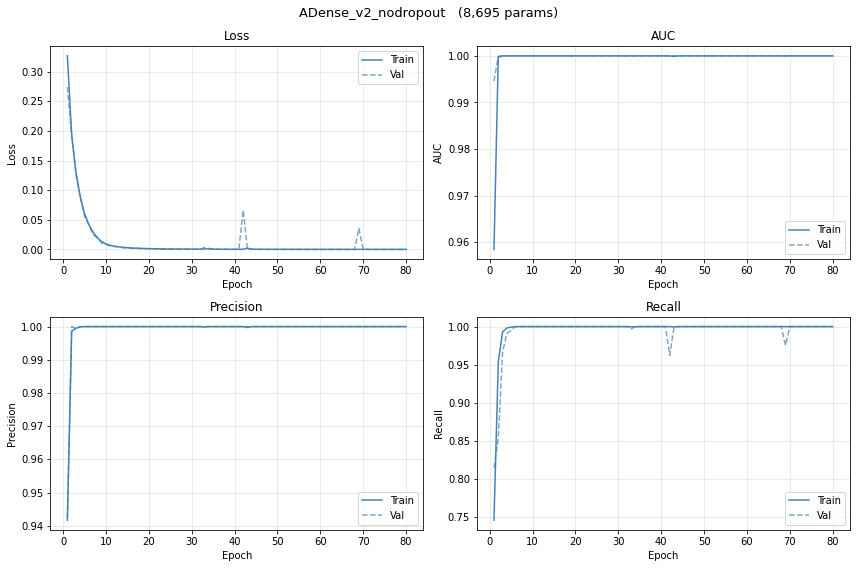

  Saved confusion matrix -> plots/confusion_ADense_v2_nodropout.png


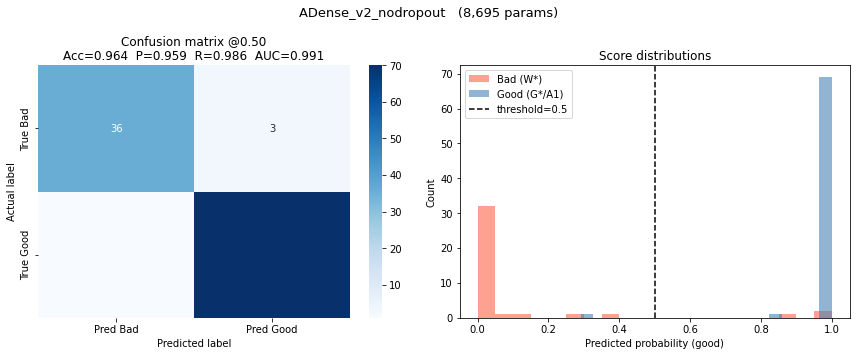

Comparing 0.9636363636363636 > 0.9636363636363636
  Model ADense_v2_nodropout did not beat @dev.
🏃 View run A13 - ADense_v2_nodropout at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/340b29b65fb446b2a4f555d8b995c48c
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
✅ Seed set to 42
  Fold  1 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  2 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  3 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  4 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  5 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  6 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  7 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=8  FP=0  TN=3  FN=0
  Fold  8 | AUC=1.000  Acc=0.909  P=0.875  R=1.000  TP=7  FP=1  TN=3  FN=0
  Fold  9 | AUC=1.000  Acc=1.000  P=1.000  R=1.00

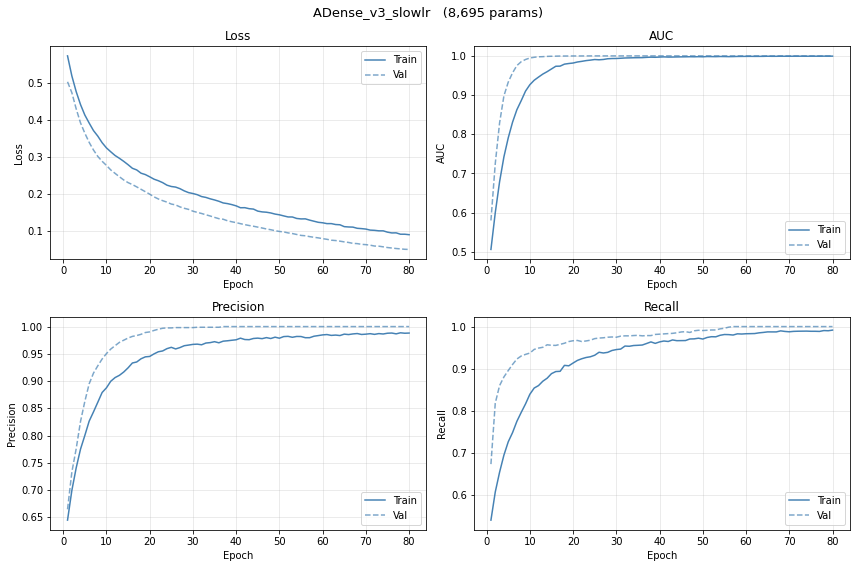

  Saved confusion matrix -> plots/confusion_ADense_v3_slowlr.png


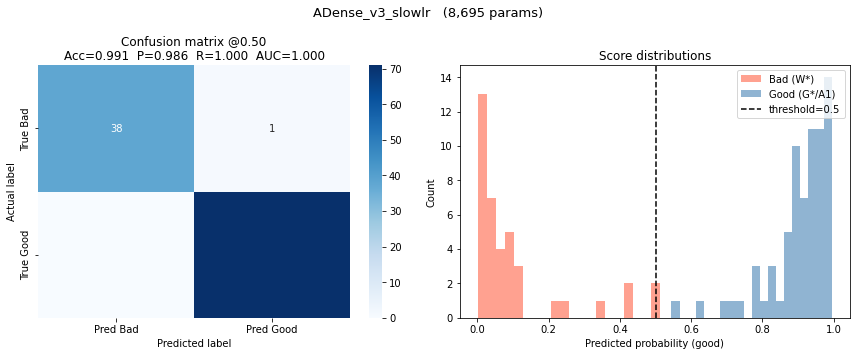

Comparing 0.990909090909091 > 0.9636363636363636
New Best! 0.990909090909091  0.9636363636363636. Updating models on DagsHub


2026/05/12 21:59:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 22:00:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'GoodBad_ClassifierV2' already exists. Creating a new version of this model...
2026/05/12 22:00:19 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: GoodBad_ClassifierV2, version 8
Created version '8' of model 'GoodBad_ClassifierV2'.


Model ADense_v3_slowlr registered -> @dev (v8)
🏃 View run A13 - ADense_v3_slowlr at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/cb2e820a7fe44683a336cb3adf75efc1
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
✅ Seed set to 42
  Fold  1 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  2 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  3 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  4 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  5 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  6 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  7 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=8  FP=0  TN=3  FN=0
  Fold  8 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  9 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=6  FP=0  TN=5  FN=0
  Fold 10 | AUC=1.000  Acc=

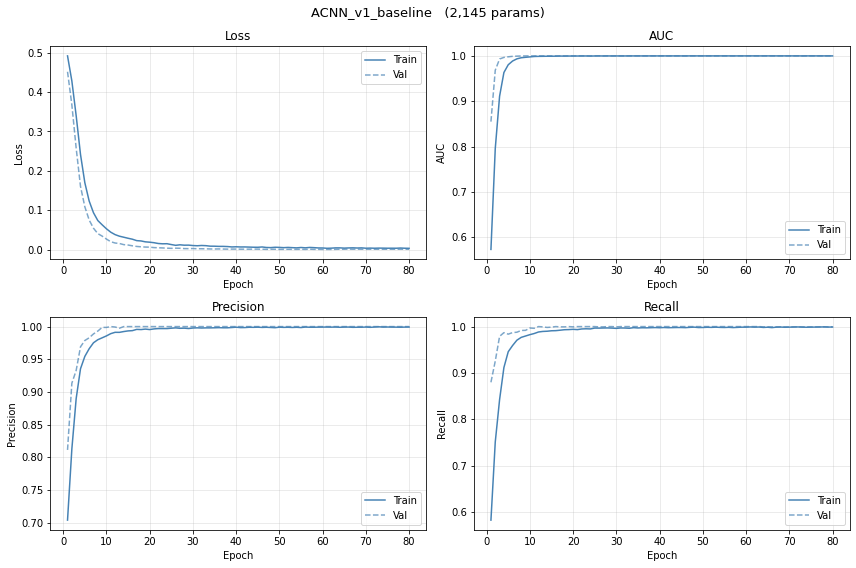

  Saved confusion matrix -> plots/confusion_ACNN_v1_baseline.png


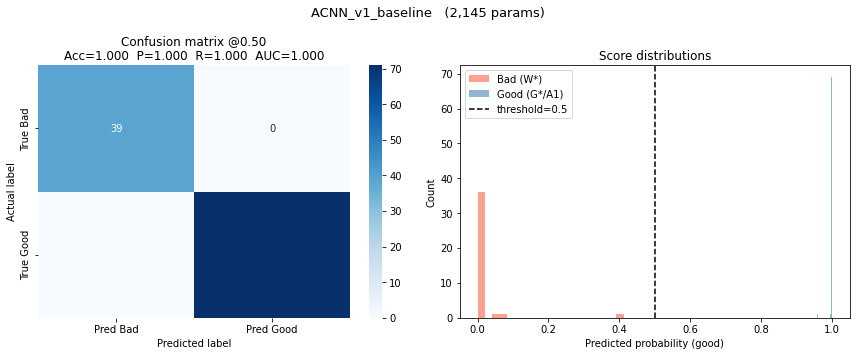

Comparing 1.0 > 0.990909090909091
New Best! 1.0  0.990909090909091. Updating models on DagsHub
Deleting old backup model.


2026/05/12 22:01:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 22:02:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'GoodBad_ClassifierV2' already exists. Creating a new version of this model...
2026/05/12 22:02:09 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: GoodBad_ClassifierV2, version 9
Created version '9' of model 'GoodBad_ClassifierV2'.


Model ACNN_v1_baseline registered -> @dev (v9)
🏃 View run A13 - ACNN_v1_baseline at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/71b44774347140c6a20fecbc327bf741
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
✅ Seed set to 42
  Fold  1 | AUC=1.000  Acc=0.909  P=0.875  R=1.000  TP=7  FP=1  TN=3  FN=0
  Fold  2 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  3 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  4 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  5 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  6 | AUC=1.000  Acc=0.909  P=1.000  R=0.857  TP=6  FP=0  TN=4  FN=1
  Fold  7 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=8  FP=0  TN=3  FN=0
  Fold  8 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  9 | AUC=0.933  Acc=0.909  P=0.857  R=1.000  TP=6  FP=1  TN=4  FN=0
  Fold 10 | AUC=1.000  Acc=

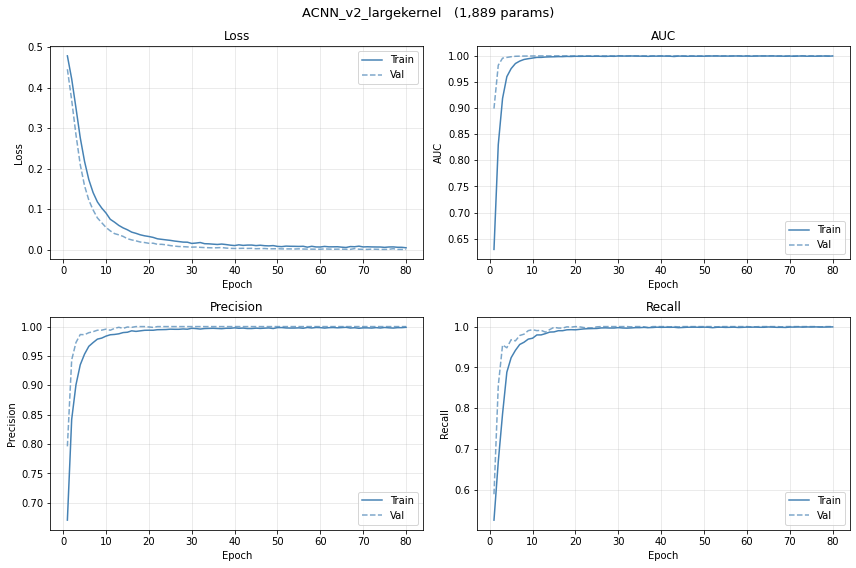

  Saved confusion matrix -> plots/confusion_ACNN_v2_largekernel.png


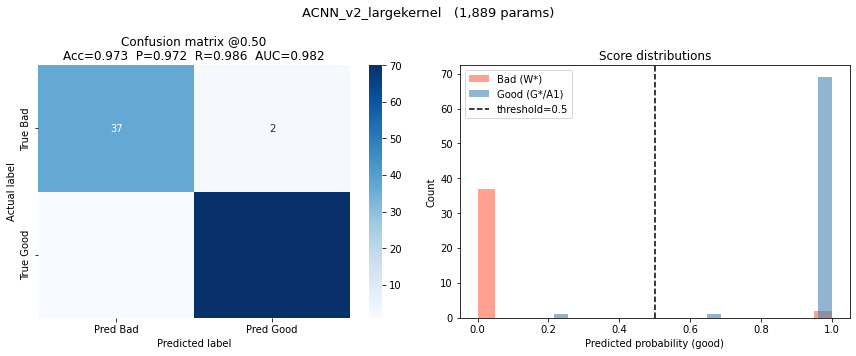

Comparing 0.9727272727272727 > 1.0
  Model ACNN_v2_largekernel did not beat @dev.
🏃 View run A13 - ACNN_v2_largekernel at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/3929d7dd95e241d8a7ebfd0a2fb08965
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0
✅ Seed set to 42
  Fold  1 | AUC=1.000  Acc=0.909  P=0.875  R=1.000  TP=7  FP=1  TN=3  FN=0
  Fold  2 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  3 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  4 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  5 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  6 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  7 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=8  FP=0  TN=3  FN=0
  Fold  8 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=7  FP=0  TN=4  FN=0
  Fold  9 | AUC=1.000  Acc=1.000  P=1.000  R=1.000  TP=6  FP=0  

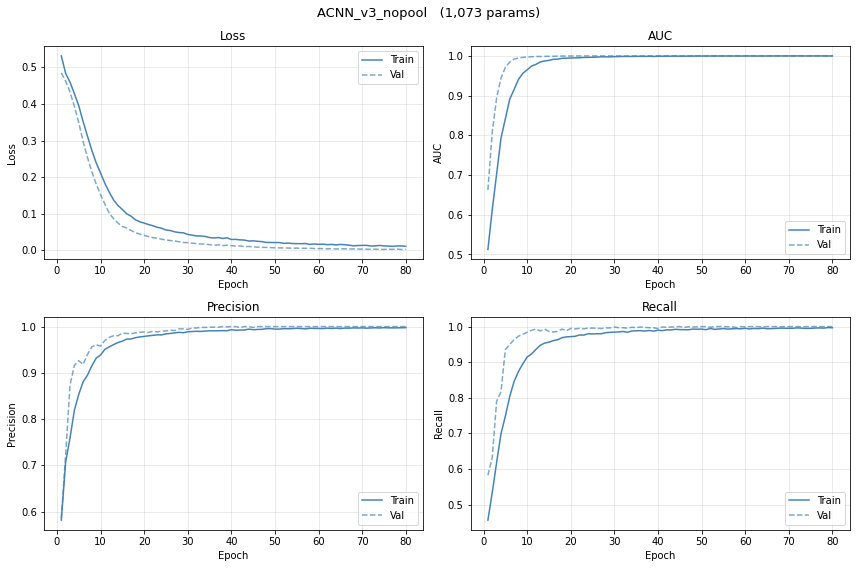

  Saved confusion matrix -> plots/confusion_ACNN_v3_nopool.png


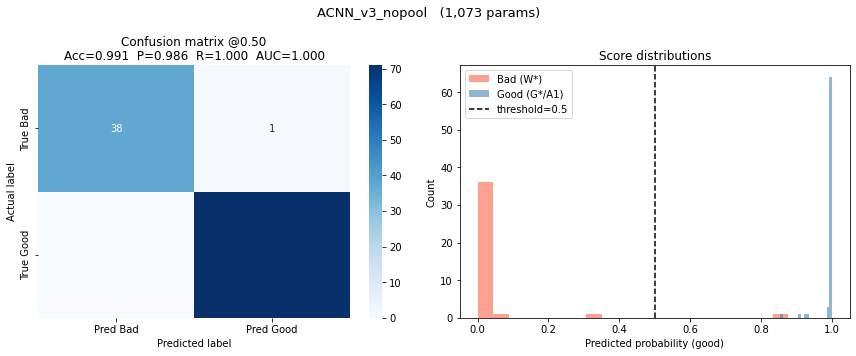

Comparing 0.990909090909091 > 1.0
  Model ACNN_v3_nopool did not beat @dev.
🏃 View run A13 - ACNN_v3_nopool at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/c5cea3ea0810481ab1d022e3307137e4
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0

=== All variants complete — generating comparison chart ===
  Saved comparison -> plots/comparison_all_variants.png


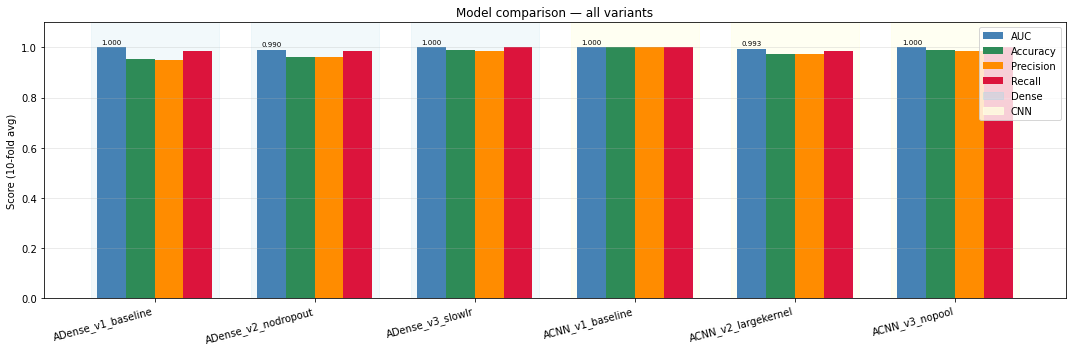

Comparison chart saved -> plots/comparison_all_variants.png


In [ ]:
N_VARIANTS_PER = len(generate_variants(raw_sequences[0][0], raw_sequences[0][3]))
orig_indices   = np.arange(0, len(augmented_pool), N_VARIANTS_PER)


def build_model(config):
    mt = config['model_type']
    if mt == 'dense':
        return ADense(INPUT_DENSE, config['h1'], config['h2'], config['dropout'])
    return ACNN(N_FEAT, C, config['n_filters'], config['kernel_size'],
                config['pool_size'], config['fc_h'], config['dropout'])


def get_X(config, indices):
    if config['model_type'] == 'dense':
        return X_flat[indices]
    return X_seq[indices]


all_variant_results = []



for config in ALL_VARIANTS:
    set_seed(SEED)

    note        = config['note']
    ckpt_path   = f'goodbad_best_{note}.pth'
    scaler_path = f'scaler_goodbad_{note}.joblib'
    for p in (ckpt_path, scaler_path):
        if os.path.exists(p): os.remove(p)

    best_overall_auc    = -1.0
    best_config_for_run = config.copy()

    gkf         = GroupKFold(n_splits=N_FOLDS)
    orig_groups = grp_all[orig_indices]
    orig_y      = y_all[orig_indices]

    _demo_model = build_model(config)
    n_params    = count_params(_demo_model)
    del _demo_model

    with mlflow.start_run(run_name=f'A13 - {note}') as run:
        log_cfg = {k: v for k, v in config.items()}
        log_cfg.update({'c_frames': C, 'n_features': N_FEAT,
                        'input_dim': INPUT_DENSE, 'n_params': n_params})
        mlflow.log_params(log_cfg)

        fold_results  = []
        fold_histories = []
        agg_labels, agg_preds, agg_probs = [], [], []

        for fold, (train_orig_pos, test_orig_pos) in enumerate(
            gkf.split(orig_indices, orig_y, orig_groups)
        ):
            train_groups = set(orig_groups[train_orig_pos])
            test_groups  = set(orig_groups[test_orig_pos])

            train_mask = np.array([g in train_groups for g in grp_all])
            orig_set   = set(orig_indices.tolist())
            test_mask  = np.array(
                [idx in orig_set and grp_all[idx] in test_groups
                 for idx in range(len(grp_all))]
            )

            X_train_raw = get_X(config, np.where(train_mask)[0])
            y_train     = y_all[train_mask]
            X_test_raw  = get_X(config, np.where(test_mask)[0])
            y_test      = y_all[test_mask]

            scaler = None
            if config.get('use_scaling'):
                scaler = MinMaxScaler()
                flat_train = X_train_raw.reshape(len(X_train_raw), -1)
                scaler.fit(flat_train)
                X_train_s = scaler.transform(flat_train).reshape(X_train_raw.shape)
                X_test_s  = scaler.transform(
                    X_test_raw.reshape(len(X_test_raw), -1)
                ).reshape(X_test_raw.shape)
            else:
                X_train_s, X_test_s = X_train_raw, X_test_raw

            shuf      = np.random.permutation(len(X_train_s))
            X_train_s = X_train_s[shuf]
            y_train   = y_train[shuf]
            val_split = int(len(X_train_s) * 0.9)
            X_tr,  X_val = X_train_s[:val_split], X_train_s[val_split:]
            y_tr,  y_val = y_train[:val_split],   y_train[val_split:]

            train_loader = DataLoader(
                GoodBadDataset(X_tr,  y_tr),
                batch_size=config['batch_size'], shuffle=True, drop_last=True
            )
            val_loader = DataLoader(
                GoodBadDataset(X_val, y_val),
                batch_size=config['batch_size'], shuffle=False
            )
            test_loader = DataLoader(
                GoodBadDataset(X_test_s, y_test),
                batch_size=config['batch_size'], shuffle=False
            )

            model     = build_model(config).to(device)
            optimizer = optim.Adam(model.parameters(), lr=config['lr'])
            pos_w     = compute_pos_weight_array(y_tr, device)
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

            best_vl, patience_ctr = float('inf'), 0
            fold_ckpt = f'fold_{fold}_{note}.pth'

            history = {
                'train_loss': [], 'val_loss': [],
                'train_auc':  [], 'val_auc':  [],
                'train_prec': [], 'val_prec': [],
                'train_rec':  [], 'val_rec':  [],
            }

            for epoch in range(config['epochs']):
                tr_loss, tr_auc, tr_prec, tr_rec = run_epoch(
                    model, train_loader, optimizer, criterion, device, train=True)
                vl_loss, vl_auc, vl_prec, vl_rec = run_epoch(
                    model, val_loader,   optimizer, criterion, device, train=False)

                history['train_loss'].append(tr_loss)
                history['val_loss'].append(vl_loss)
                history['train_auc'].append(tr_auc)
                history['val_auc'].append(vl_auc)
                history['train_prec'].append(tr_prec)
                history['val_prec'].append(vl_prec)
                history['train_rec'].append(tr_rec)
                history['val_rec'].append(vl_rec)

                if vl_loss < best_vl:
                    best_vl, patience_ctr = vl_loss, 0
                    torch.save(model.state_dict(), fold_ckpt)
                else:
                    patience_ctr += 1
                    if patience_ctr >= config['patience']:
                        break

            fold_histories.append(history)

            model.load_state_dict(torch.load(fold_ckpt, weights_only=True))
            m = evaluate_metrics(model, test_loader, device)
            m['fold'] = fold + 1
            fold_results.append(m)

            agg_labels.extend(m['labels'].tolist())
            agg_preds.extend(m['preds'].tolist())
            agg_probs.extend(m['probs'].tolist())

            print(f'  Fold {fold+1:2d} | '
                  f'AUC={m["AUC"]:.3f}  Acc={m["accuracy"]:.3f}  '
                  f'P={m["precision"]:.3f}  R={m["recall"]:.3f}  '
                  f'TP={m["TP"]}  FP={m["FP"]}  TN={m["TN"]}  FN={m["FN"]}')

            if m['AUC'] > best_overall_auc:
                best_overall_auc    = m['AUC']
                best_config_for_run = config.copy()
                torch.save(model.state_dict(), ckpt_path)
                if scaler is not None:
                    joblib.dump(scaler, scaler_path)

            if os.path.exists(fold_ckpt):
                os.remove(fold_ckpt)

        auc_vals  = [r['AUC']       for r in fold_results]
        acc_vals  = [r['accuracy']  for r in fold_results]
        prec_vals = [r['precision'] for r in fold_results]
        rec_vals  = [r['recall']    for r in fold_results]

        avg_auc  = float(np.mean(auc_vals))
        avg_acc  = float(np.mean(acc_vals))
        avg_prec = float(np.mean(prec_vals))
        avg_rec  = float(np.mean(rec_vals))

        mlflow.log_metric('mean_AUC',       avg_auc)
        mlflow.log_metric('mean_accuracy',  avg_acc)
        mlflow.log_metric('mean_precision', avg_prec)
        mlflow.log_metric('mean_recall',    avg_rec)
        mlflow.log_metric('best_fold_AUC',  best_overall_auc)
        mlflow.log_metric('n_params',       n_params)

        print(f'\n--- {note} ({n_params:,} params) ---')
        print(f'10-fold averages: AUC={avg_auc:.4f}  Acc={avg_acc:.4f}  '
              f'Prec={avg_prec:.4f}  Rec={avg_rec:.4f}')

        curves_path = plot_training_curves(fold_histories, note, n_params)
        mlflow.log_artifact(curves_path)

        agg_l = np.array(agg_labels)
        agg_d = np.array(agg_preds)
        agg_p = np.array(agg_probs)
        agg_metrics = {
            'AUC':       float(roc_auc_score(agg_l, agg_p)),
            'accuracy':  accuracy_score(agg_l, agg_d),
            'precision': precision_score(agg_l, agg_d, zero_division=0),
            'recall':    recall_score(agg_l, agg_d, zero_division=0),
        }
        cm_path = plot_confusion_matrix_variant(
            agg_l, agg_d, agg_p, note, agg_metrics, n_params
        )
        mlflow.log_artifact(cm_path)

        rpt = pd.DataFrame([{
            'fold': r['fold'], 'AUC': r['AUC'], 'accuracy': r['accuracy'],
            'precision': r['precision'], 'recall': r['recall'],
            'TP': r['TP'], 'FP': r['FP'], 'TN': r['TN'], 'FN': r['FN'],
        } for r in fold_results])
        rpt_path = f'fold_results_{note}.csv'
        rpt.to_csv(rpt_path, index=False)
        mlflow.log_artifact(rpt_path)

        all_variant_results.append({
            'note':       note,
            'model_type': config['model_type'],
            'n_params':   n_params,
            'AUC':        avg_auc,
            'accuracy':   avg_acc,
            'precision':  avg_prec,
            'recall':     avg_rec,
        })

        if utils.auto_check_challenger(run.info.run_id, metric_name='mean_accuracy') \
                and os.path.exists(ckpt_path):
            model_to_log = build_model(best_config_for_run).to(device)
            model_to_log.load_state_dict(
                torch.load(ckpt_path, map_location=device, weights_only=True))
            mlflow.pytorch.log_model(
                model_to_log, 'model', registered_model_name=A13_PROJECT
            )
            if os.path.exists(scaler_path):
                mlflow.log_artifact(scaler_path)
            latest_v = utils.client.get_latest_versions(A13_PROJECT)[0].version
            utils.client.set_registered_model_alias(A13_PROJECT, 'dev', latest_v)
            print(f'Model {note} registered -> @dev (v{latest_v})')
        else:
            print(f'  Model {note} did not beat @dev.')

        for p in (ckpt_path, scaler_path):
            if os.path.exists(p):
                os.remove(p)




# Manual checkning of already preprocessed files

In [ ]:
def load_goodbad_alias(alias, project_name, device):
    client  = mlflow.MlflowClient()
    version = client.get_model_version_by_alias(project_name, alias)
    run     = client.get_run(version.run_id)
    model   = mlflow.pytorch.load_model(
        f'models:/{project_name}@{alias}', map_location=device
    ).to(device)
    model.eval()
    scaler = None
    try:
        artifacts = client.list_artifacts(version.run_id)
        scaler_artifact = next(
            (a.path for a in artifacts if a.path.startswith('scaler_goodbad')),
            None
        )
        if scaler_artifact:
            p      = client.download_artifacts(version.run_id, scaler_artifact)
            scaler = joblib.load(p)
    except Exception as e:
        print(f'  No scaler loaded: {e}')
    mt   = run.data.params.get('model_type', 'dense')
    note = run.data.params.get('note', '?')
    print(f'Loaded @{alias}: {note}  model_type={mt}  scaler={"yes" if scaler else "no"}')
    return model, scaler, mt

clf_model, clf_scaler, clf_type = load_goodbad_alias('prod', A13_PROJECT, device)


def classify_cut_sequence(filepath, clf_model, clf_scaler, clf_type, device,
                           feat_cols=FEAT_COLS):
    df  = pd.read_csv(filepath)
    arr = df[feat_cols].values.astype('float32')

    enriched = add_dist_angle_features(arr, feat_cols)
    fixed    = to_fixed_length(enriched, C)

    X = fixed.flatten()[None, :] if clf_type == 'dense' else fixed[None, :, :]

    if clf_scaler is not None:
        X = clf_scaler.transform(X.reshape(1, -1)).reshape(X.shape)

    clf_model.eval()
    with torch.no_grad():
        prob_good = torch.sigmoid(
            clf_model(torch.tensor(X, dtype=torch.float32, device=device))
        ).item()

    return prob_good, ('Good' if prob_good >= 0.5 else 'Bad')


# B6 is squat 
# B5 is not
# A1 is squat

TEST_FILE = "../../data/kinect_good_preprocessed_A9_mediapipe/B5_kinect.csv"

prob, pred = classify_cut_sequence(
    TEST_FILE, clf_model, clf_scaler, clf_type, device
)

print(f'File    : {os.path.basename(TEST_FILE)}')
print(f'P(Good) : {prob:.3f}')
print(f'Pred    : {pred}')


Loaded @prod: ACNN_v1  model_type=cnn  scaler=yes
File    : B5_kinect.csv
P(Good) : 0.000
Pred    : Bad
